<a href="https://colab.research.google.com/github/rasyadtanzilur/pengolahancitra/blob/main/Minggu%203%20Praktikum_PERBAIKAN_CITRA_DALAM_DOMAIN_SPASIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

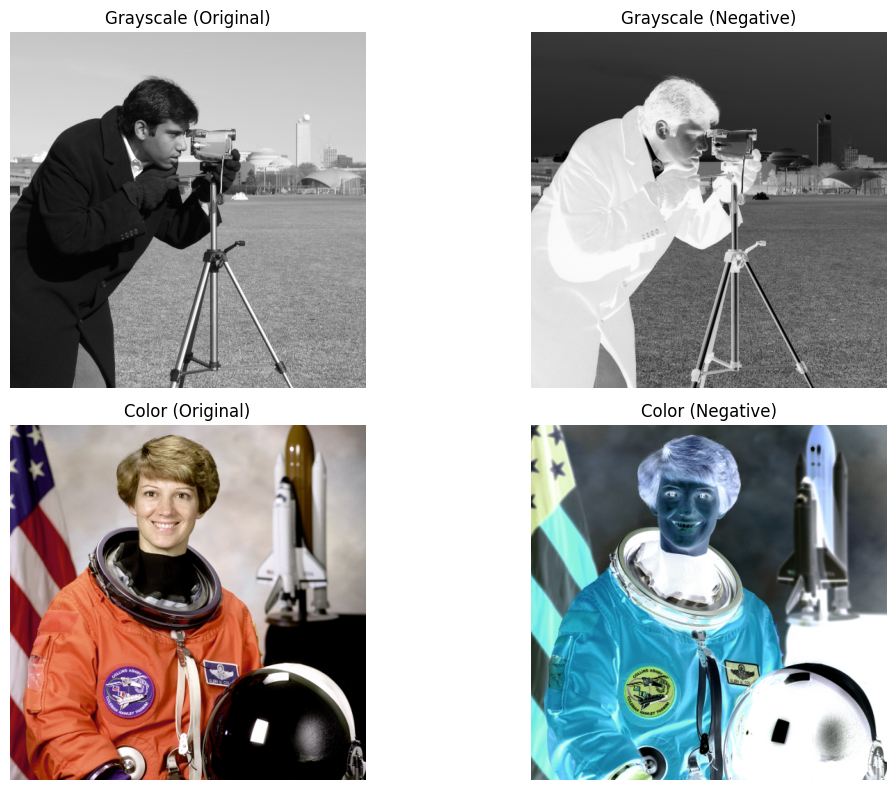

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# ===================
# 1. TRANSFORMASI NEGATIF CITRA GRAYSCALE
# ===================
image_gray_uint8 = data.camera()  # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8)  # Konversi ke float [0..1]

negative_gray = 1.0 - image_gray_float  # Inversi intensitas: output = 1 - input

# ===================
# 2. TRANSFORMASI NEGATIF CITRA BERWARNA
# ===================
image_color_uint8 = data.astronaut()  # Citra berwarna (512x512x3, 0..255)
image_color_float = img_as_float(image_color_uint8)  # Konversi ke float [0..1]

negative_color = 1.0 - image_color_float  # Inversi intensitas tiap kanal RGB

# ===================
# 3. PLOTTING HASIL
# ===================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Baris 1: Grayscale (original, negative)
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# Baris 2: RGB (original, negative)
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

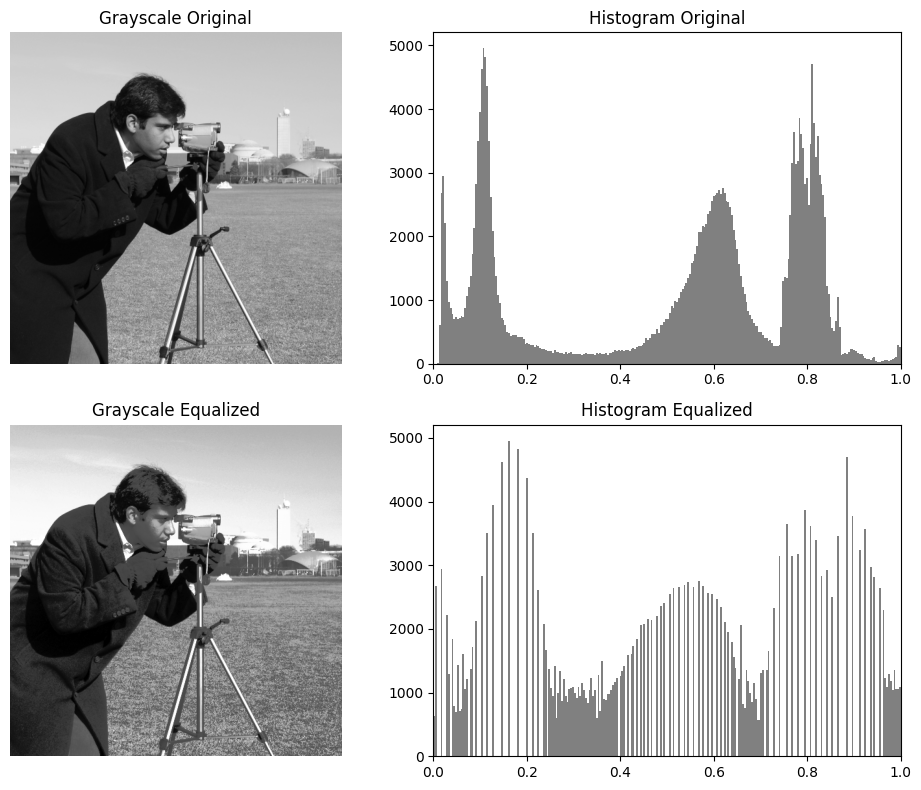

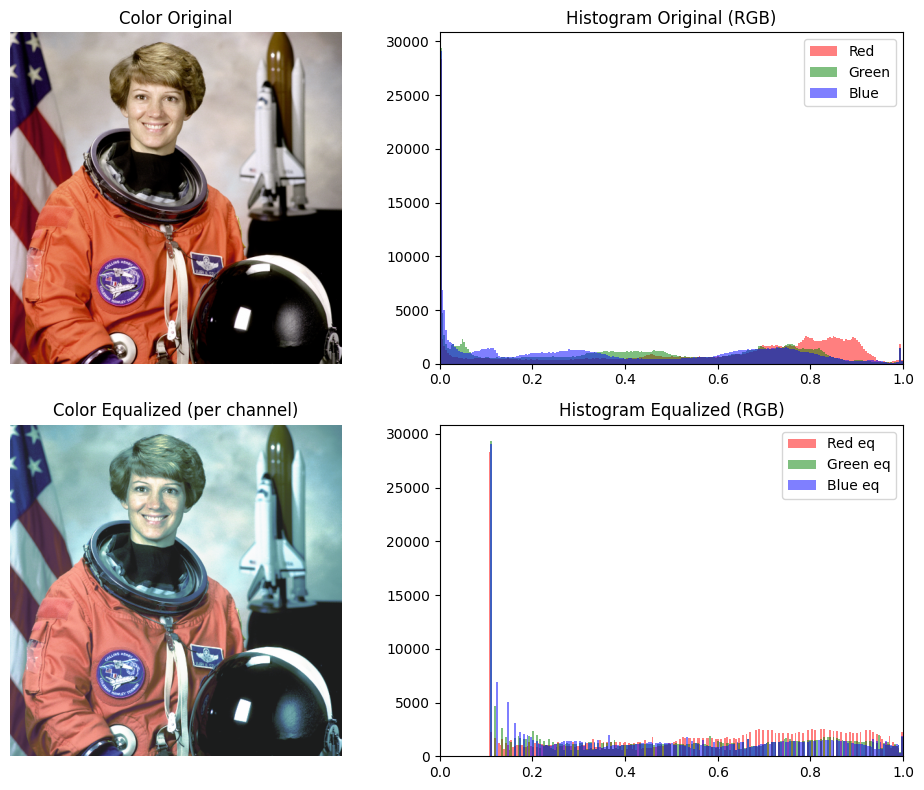

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# ======================= BAGIAN 1: HISTOGRAM GRAYSCALE =======================
# 1. Muat citra grayscale (uint8 -> float)
image_gray_uint8 = data.camera()
image_gray = img_as_float(image_gray_uint8)

# 2. Histogram citra asli
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram grayscale
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0, 1))

# 4. Visualisasi grayscale
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

# (b) Histogram Asli
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0, 1)

# (c) Citra Ekualisasi
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

# (d) Histogram Ekualisasi
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

# ===================== BAGIAN 2: HISTOGRAM CITRA BERWARNA =====================
# 1. Muat citra RGB (uint8 -> float)
image_color_uint8 = data.astronaut()
image_color = img_as_float(image_color_uint8)

# 2. Pisahkan kanal R, G, B
r_channel = image_color[:, :, 0]
g_channel = image_color[:, :, 1]
b_channel = image_color[:, :, 2]

# 3. Histogram kanal R, G, B
hist_r, _ = np.histogram(r_channel.ravel(), bins=256, range=(0, 1))
hist_g, _ = np.histogram(g_channel.ravel(), bins=256, range=(0, 1))
hist_b, _ = np.histogram(b_channel.ravel(), bins=256, range=(0, 1))

# 4. Ekualisasi histogram per kanal
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

# Gabungkan kembali citra RGB hasil ekualisasi
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Histogram kanal hasil ekualisasi
hist_r_eq, _ = np.histogram(r_eq.ravel(), bins=256, range=(0, 1))
hist_g_eq, _ = np.histogram(g_eq.ravel(), bins=256, range=(0, 1))
hist_b_eq, _ = np.histogram(b_eq.ravel(), bins=256, range=(0, 1))

# 5. Visualisasi hasil warna
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli RGB
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

# (b) Histogram Asli RGB
axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0, 1)
axes2[0, 1].legend(loc='upper right')

# (c) Citra RGB setelah Ekualisasi
axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (per channel)")
axes2[1, 0].axis('off')

# (d) Histogram RGB setelah Ekualisasi
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0, 1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()


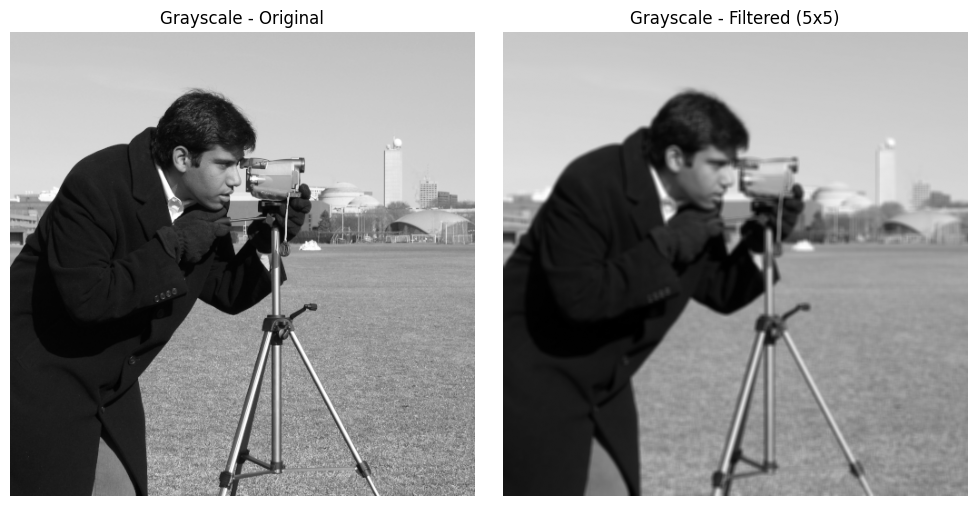

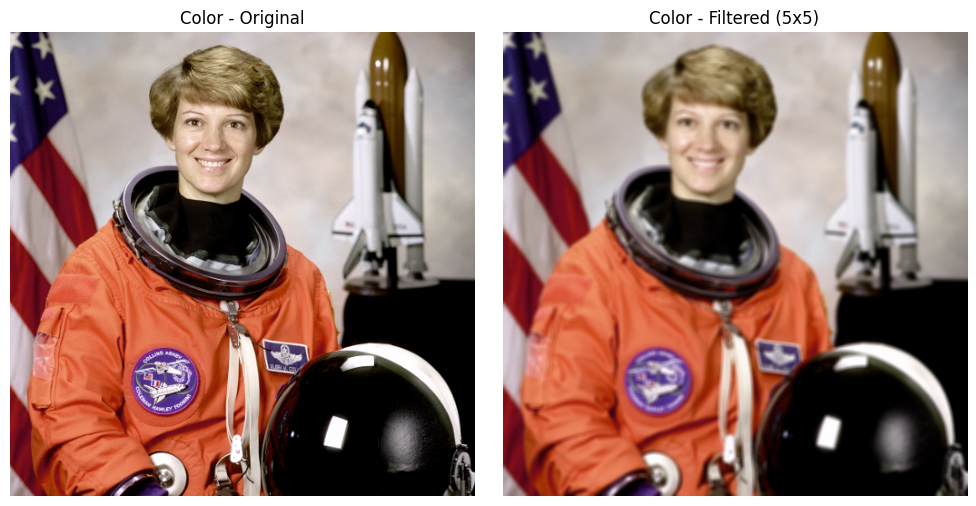

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# ====================================================
# 1) FILTER RATA-RATA PADA CITRA GRAYSCALE
# ====================================================

# A. Memuat citra grayscale
gray_uint8 = data.camera()  # uint8, range 0..255
gray_img = img_as_float(gray_uint8)  # konversi ke float [0..1]

# B. Definisikan kernel rata-rata 5x5
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Terapkan filter (konvolusi)
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# D. Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# ====================================================
# 2) FILTER RATA-RATA PADA CITRA BERWARNA (RGB)
# ====================================================

# A. Memuat citra RGB
color_uint8 = data.astronaut()  # uint8, range 0..255
color_img = img_as_float(color_uint8)  # konversi ke float [0..1]

# B. Terapkan filter rata-rata ke tiap kanal R, G, B
color_filtered = np.zeros_like(color_img)
for c in range(3):  # R, G, B
    channel = color_img[:, :, c]
    color_filtered[:, :, c] = ndi.convolve(channel, kernel, mode='reflect')

# C. Visualisasi
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size})")
axes2[1].axis('off')

plt.tight_layout()
plt.show()
